# Lab 4.1. Простая RNN

PyTorch предлагает несколько слоев и опций для RNN.<br>
* <a href='https://pytorch.org/docs/stable/nn.html#rnn'><tt><strong>torch.nn.RNN()</strong></tt></a> предоставляет базовую модель, которая применяет многослойный RNN с нелинейными функциями <em> tanh </em> или <em> ReLU </em> ко входной последовательности. <br>
Однако, как мы знаем, у vanilla RNN есть свои ограничения. <br> <br>
* <a href='https://pytorch.org/docs/stable/nn.html#lstm'> <tt> <strong> torch.nn.LSTM () </strong> </tt> </a> добавляет LSTM, который значительно расширяет память RNN.

## LSTM
Для каждого элемента входной последовательности LSTM вычисляет следующие функции: <br>
$\begin{array}{ll} \\
    i_t = \sigma(W_{ii} x_t + b_{ii} + W_{hi} h_{(t-1)} + b_{hi}) \\
    f_t = \sigma(W_{if} x_t + b_{if} + W_{hf} h_{(t-1)} + b_{hf}) \\
    g_t = \tanh(W_{ig} x_t + b_{ig} + W_{hg} h_{(t-1)} + b_{hg}) \\
    o_t = \sigma(W_{io} x_t + b_{io} + W_{ho} h_{(t-1)} + b_{ho}) \\
    c_t = f_t * c_{(t-1)} + i_t * g_t \\
    h_t = o_t * \tanh(c_t) \\
\end{array}$


Чтобы продемонстрировать потенциал LSTM, мы рассмотрим простую синусоидальную волну. Наша цель, предсказать следующее значение в последовательности. Из-за циклической природы синусоидальной волны типичная нейронная сеть не будет знать, должна ли она прогнозировать восходящий или нисходящий тренд, в то время как LSTM способен это делать.

## Импорт

In [1]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Создаем датасет
Для этого упражнения мы рассмотрим простую синусоиду. Мы возьмем 800 точек данных и назначим 40 точек за полный период, всего 20 полных периодов. Мы будем обучать нашу модель по всем данным, кроме последнего периода, и будем использовать последний период для оценки наших тестовых прогнозов.

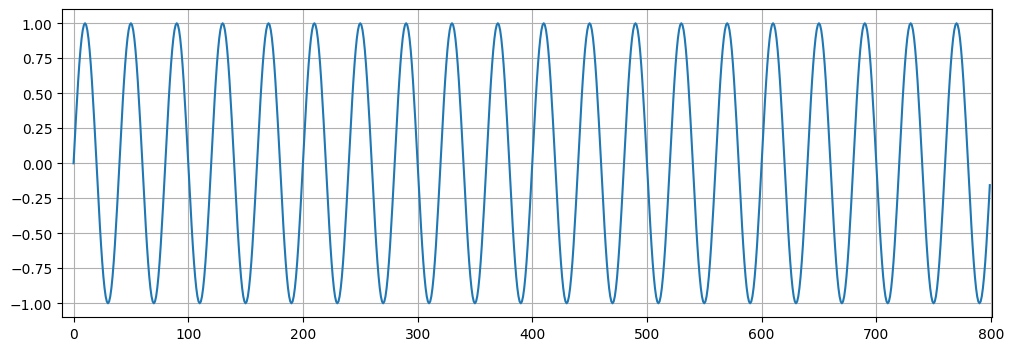

In [2]:
# Create & plot data points
x = torch.linspace(0,799,steps=800)
y = torch.sin(x*2*3.1416/40)

plt.figure(figsize=(12,4))
plt.xlim(-10,801)
plt.grid(True)
plt.plot(y.numpy());

## Создание обучающего и тестового наборов
Мы хотим взять первые 760 точек из нашей последовательности в качестве обучающей последовательности, а последние 40 - для тестирования.

In [3]:
test_size = 40

train_set = y[:-test_size]
test_set = y[-test_size:]

## Подготовка обучающего множества

При работе с моделями LSTM мы начинаем с разделения обучающей последовательности на серию перекрывающихся «окон». Каждое окно состоит из последовательности точек. Метка, используемая для обучения, равна следующему значению в последовательности. Таким образом, наша сеть узнает, какое значение должно следовать заданному шаблону на основе  предыдущих значений. Примечание: хотя слой LSTM создает прогнозное значение для каждого элемента в окне, нам нужен только последний.

Например, скажем, у нас есть последовательность из 15 записей и размер окна 5. Мы подаем в модель $ [x_1, .., x_5] $ и сравниваем прогноз с $ x_6 $. Затем мы выполняем backprop, обновляем параметры и подаем в модель $ [x_2, .., x_6] $. Мы получаем новый выход, который сравниваем с $ x_7 $ и т. д. До $ [x_ {10}, .., x_ {14}] $.

Чтобы упростить задачу, мы определим функцию с именем <tt> input_data </tt>, которая создает список кортежей <tt> (seq, label) </tt>. Окна перекрываются, поэтому первый кортеж может содержать $ ([x_1, .., x_5], [x_6]) $, второй - $ ([x_2, .., x_6], [x_7]) $ и т. д.

Здесь $ k $ - ширина окна. Из-за перекрытия у нас будет общее количество кортежей <tt> (seq, label) </tt>, равное $ \textrm{len}(series) -k $

In [4]:
def input_data(seq,ws):  # ws размер окна
    out = []
    L = len(seq)
    for i in range(L-ws):
        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1]
        out.append((window,label))
    return out

<div class = "alert alert-info"> <strong> ПРИМЕЧАНИЕ. </strong> «окно» отличается от «батча». В нашем примере мы будем подавать по одному окну в модель за раз, поэтому размер нашего батча будет равен 1. Если мы передадим два окна в модель до того, как сделаем backprop и обновим веса, размер нашего батча будет равен 2. </div>

Для обучения нашим синусоидальным данным мы будем использовать размер окна 40 (один полный период).

In [5]:

# test_size = 40
# train_set = y[:-test_size]
# test_set = y[-test_size:]

window_size = 40

# Создать обучающий набор данных, состоящий из последовательности и метки :
train_data = input_data(train_set,window_size)

len(train_data) # должно быть 760-40

720

In [6]:
# Печатем данные из обучающего набора
train_data[0]

(tensor([ 0.0000e+00,  1.5643e-01,  3.0902e-01,  4.5399e-01,  5.8779e-01,
          7.0711e-01,  8.0902e-01,  8.9101e-01,  9.5106e-01,  9.8769e-01,
          1.0000e+00,  9.8769e-01,  9.5106e-01,  8.9100e-01,  8.0901e-01,
          7.0710e-01,  5.8778e-01,  4.5398e-01,  3.0901e-01,  1.5643e-01,
         -7.2400e-06, -1.5644e-01, -3.0902e-01, -4.5400e-01, -5.8779e-01,
         -7.0711e-01, -8.0902e-01, -8.9101e-01, -9.5106e-01, -9.8769e-01,
         -1.0000e+00, -9.8769e-01, -9.5105e-01, -8.9100e-01, -8.0901e-01,
         -7.0710e-01, -5.8777e-01, -4.5398e-01, -3.0900e-01, -1.5642e-01]),
 tensor([1.4480e-05]))

In [7]:
torch.set_printoptions(sci_mode=False) # другой способ просмотра тензора
train_data[0]

(tensor([ 0.0000,  0.1564,  0.3090,  0.4540,  0.5878,  0.7071,  0.8090,  0.8910,
          0.9511,  0.9877,  1.0000,  0.9877,  0.9511,  0.8910,  0.8090,  0.7071,
          0.5878,  0.4540,  0.3090,  0.1564, -0.0000, -0.1564, -0.3090, -0.4540,
         -0.5878, -0.7071, -0.8090, -0.8910, -0.9511, -0.9877, -1.0000, -0.9877,
         -0.9511, -0.8910, -0.8090, -0.7071, -0.5878, -0.4540, -0.3090, -0.1564]),
 tensor([0.0000]))

## Определим LSTM модель
Наша модель будет иметь один слой LSTM с входным размером 1 и скрытым размером 50, за которым следует полносвязный слой, чтобы вывести прогноз размера 1. <br>
<div class = "alert alert-info"> <strong> ПРИМЕЧАНИЕ. </strong>. <em> input_dim </em> и <em> hidden_dim </em> -- то же самое что <em> input_size </em> и <em> hidden_size </em>.

Во время обучения мы пропускаем три тензора через слой LSTM - последовательность, скрытое состояние $ h_0 $ и состояние ячейки $ c_0 $. <br>

Это означает, что нам нужно инициализировать $ h_0 $ и $ c_0 $. Это можно сделать со случайными значениями, но вместо этого мы будем использовать нули.

In [8]:
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=10, out_size=1):
        super().__init__()
        self.hidden_size = hidden_size

        # Add an LSTM layer:
        self.lstm = nn.LSTM(input_size,hidden_size)

        # Add a fully-connected layer:
        self.linear = nn.Linear(hidden_size, out_size)

        # Initialize h0 and c0:
        self.hidden = (torch.zeros(1,1,hidden_size),
                       torch.zeros(1,1,hidden_size))

    def forward(self,seq):
        lstm_out, self.hidden = self.lstm(seq.view(len(seq), 1, -1), self.hidden)
        pred = self.linear(lstm_out.view(len(seq),-1))
#         print(len(pred))
#         print(self.hidden[0])
#         print(lstm_out)
        return pred[-1]   # нам нужно только последнее значение

## Создаем модель, определяем функцию потерь и оптимизатор
Поскольку мы сравниваем отдельные значения, мы будем использовать <a href='https://pytorch.org/docs/stable/nn.html#mseloss'> <tt> <strong> torch.nn.MSELoss </strong > </tt> </a> <br> Используем <a href='https://pytorch.org/docs/stable/optim.html#torch.optim.SGD'> <tt> <strong> torch.optim.SGD </strong> </tt> </a> вместо <a href = 'https: //pytorch.org/docs/stable/optim.html#torch.optim.Adam '> <tt> <strong> torch.optim.Adam </strong> </tt> </a>

In [9]:
torch.manual_seed(42)
model = LSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

model

LSTM(
  (lstm): LSTM(1, 10)
  (linear): Linear(in_features=10, out_features=1, bias=True)
)

In [10]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')

count_parameters(model)

    40
   400
    40
    40
    10
     1
______
   531


## Предсказываем значения
Чтобы показать, как модель LSTM улучшается после каждой эпохи, мы выполним предсказание и построим график результатов. Наша цель - предсказать последнюю последовательность из 40 значений и сравнить их с известными данными в нашем тестовом наборе. Тем не менее, мы должны быть очень осторожными и <em> не </em> использовать тестовые данные в ходе получения прогноза, то есть каждое новое предсказанное значение основывается только на ранее предсказанных значениях.

Хитрость заключается в том, чтобы взять последнее известное окно, предсказать следующее значение, затем <em> добавить </em> предсказанное значение к последовательности и запустить новое предсказание в окне, которое включает в себя значение, которое мы только что предсказали

## Обучаем и оцениваем модель
Мы будем тренировать 10 эпох. Для наглядности мы «увеличим» тестовый набор и будем рассматривать его только от точки 700 до конца.

In [11]:
epochs = 10
future = 40

for i in range(epochs):
    pred2 = []
    # получаем обучающие данные
    for seq, y_train in train_data:

        # сбросить параметры и скрытые состояния
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))

        y_pred = model(seq)
        pred2.append(y_pred)
        loss = criterion(y_pred, y_train)

        loss.backward()
        optimizer.step()

    # результат обучения
    print(f'Epoch: {i+1:2} Loss: {loss.item():10.8f}')

    # Выполняем предсказание
    # начать со списка последних 40  записей из обучающего множества
    preds = train_set[-window_size:].tolist()

    for f in range(future):
        seq = torch.FloatTensor(preds[-window_size:])
        with torch.no_grad():
            model.hidden = (torch.zeros(1,1,model.hidden_size),
                            torch.zeros(1,1,model.hidden_size))
            preds.append(model(seq).item())

    loss = criterion(torch.tensor(preds[-window_size:]),y[760:])
    print(f'Loss on test predictions: {loss}')

Epoch:  1 Loss: 0.11603318
Loss on test predictions: 0.7379406094551086
Epoch:  2 Loss: 0.06400536
Loss on test predictions: 0.5639548301696777
Epoch:  3 Loss: 0.01631027
Loss on test predictions: 0.35547125339508057
Epoch:  4 Loss: 0.00428591
Loss on test predictions: 0.043530941009521484
Epoch:  5 Loss: 0.00205491
Loss on test predictions: 0.020554741844534874
Epoch:  6 Loss: 0.00123197
Loss on test predictions: 0.015956927090883255
Epoch:  7 Loss: 0.00084668
Loss on test predictions: 0.013390433974564075
Epoch:  8 Loss: 0.00064552
Loss on test predictions: 0.011566617526113987
Epoch:  9 Loss: 0.00053128
Loss on test predictions: 0.010203246027231216
Epoch: 10 Loss: 0.00046125
Loss on test predictions: 0.009169629774987698


# Прогнозирование в "туманное" будущее
Мы продолжим обучаеть нашу модель, на этот раз используя весь набор данных. Затем мы предскажем, какими должны быть <em> следующие </em> 40 точек (за пределами доступных 800 точек).

## Обучаем модель
Может занять несколько минут

In [ ]:
epochs = 10
window_size = 80
future = 160

# Обучаем на полном наборе
all_data = input_data(y,window_size)
len(all_data)  # должно быть 800-40

760

In [16]:
import time
start_time = time.time()

for i in range(epochs):
    for seq, y_train in all_data:
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))

        y_pred = model(seq)

        loss = criterion(y_pred, y_train)

        loss.backward()
        optimizer.step()

    # результат обучения
    print(f'Epoch: {i+1:2} Loss: {loss.item():10.8f}')

print(f'\nDuration: {time.time() - start_time:.0f} seconds')

Epoch:  1 Loss: 0.00023148
Epoch:  2 Loss: 0.00022159
Epoch:  3 Loss: 0.00021255
Epoch:  4 Loss: 0.00020430
Epoch:  5 Loss: 0.00019678
Epoch:  6 Loss: 0.00018990
Epoch:  7 Loss: 0.00018360
Epoch:  8 Loss: 0.00017778
Epoch:  9 Loss: 0.00017238
Epoch: 10 Loss: 0.00016728

Duration: 27 seconds


## Предсказываем и выводим графики

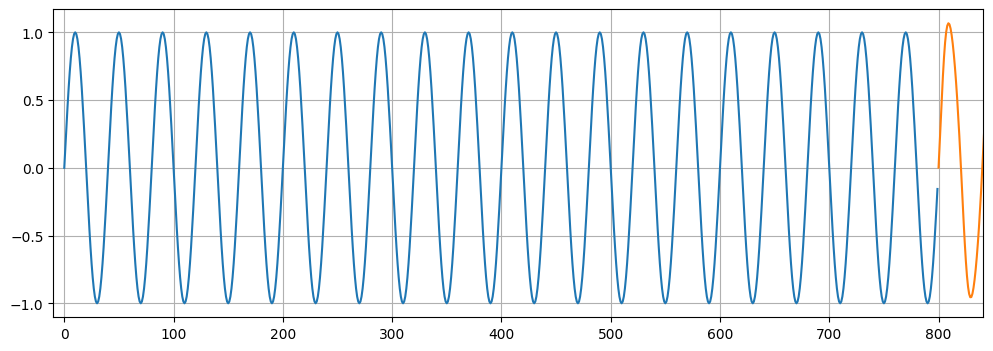

In [17]:
preds = y[-window_size:].tolist()

for i in range(future):
    seq = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad():
        #
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))
        preds.append(model(seq).item())

plt.figure(figsize=(12,4))
plt.xlim(-10,841)
plt.grid(True)
plt.plot(y.numpy())
plt.plot(range(800,800+future),preds[window_size:])
plt.show()